# Feed Handler & Order Router

**Category:** Microstructure Engines  
**Project ID:** `engines_02_feed_handler`  

Low-latency feed handler with lock-free queues, binary protocol decoding, FIX encoding, and latency tracking


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.10.19
         torch: 2.7.1+cu118
        device: CUDA (NVIDIA GeForce RTX 4090)
         numpy: 1.26.4
        pandas: 2.3.3
         scipy: 1.15.3
       sklearn: 1.7.2
    matplotlib: 3.10.8


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"queue_size": 65536}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
                 queue_size: 65536


## Feed Handler — Binary Message Encoding & Queue Simulation

In [3]:
import numpy as np, pandas as pd, struct, json, time

rng = np.random.default_rng(SEED)
n_messages = PARAMS.get("n_messages", 50_000)
queue_size = PARAMS.get("queue_size", 65536)

# --- Binary message format ---
# Market data: [seq(4B), ts(8B), symbol(8B), price(8B), size(4B), side(1B)]
msg_format = "!Id8sdIb"
msg_size = struct.calcsize(msg_format)

symbols = [b"SPY\x00\x00\x00\x00\x00", b"QQQ\x00\x00\x00\x00\x00",
           b"AAPL\x00\x00\x00\x00", b"TSLA\x00\x00\x00\x00"]

# Generate test messages
seq_nums = np.arange(1, n_messages + 1)
timestamps = np.cumsum(rng.exponential(0.0001, n_messages))
prices = 100.0 + np.cumsum(rng.normal(0, 0.001, n_messages))
sizes = rng.exponential(200, n_messages).astype(int) + 10
sides = rng.choice([0, 1], n_messages)
sym_indices = rng.choice(len(symbols), n_messages)

# --- Benchmark 3 encoding formats ---
sample_size = min(10000, n_messages)
results = {}

# 1. struct.pack (binary)
latencies_struct = np.zeros(sample_size)
for i in range(sample_size):
    t0 = time.perf_counter_ns()
    msg = struct.pack(msg_format, int(seq_nums[i]), timestamps[i],
                      symbols[sym_indices[i]], prices[i], int(sizes[i]), int(sides[i]))
    _ = struct.unpack(msg_format, msg)
    latencies_struct[i] = (time.perf_counter_ns() - t0) / 1000
results["struct"] = {"latencies": latencies_struct, "msg_size": msg_size}

# 2. JSON
latencies_json = np.zeros(sample_size)
for i in range(sample_size):
    d = {"seq": int(seq_nums[i]), "ts": float(timestamps[i]),
         "sym": symbols[sym_indices[i]].decode().strip("\x00"),
         "px": float(prices[i]), "sz": int(sizes[i]), "side": int(sides[i])}
    t0 = time.perf_counter_ns()
    encoded = json.dumps(d).encode()
    _ = json.loads(encoded)
    latencies_json[i] = (time.perf_counter_ns() - t0) / 1000
results["JSON"] = {"latencies": latencies_json, "msg_size": len(encoded)}

# 3. CSV-like (string)
latencies_csv = np.zeros(sample_size)
for i in range(sample_size):
    t0 = time.perf_counter_ns()
    encoded = f"{seq_nums[i]},{timestamps[i]},{symbols[sym_indices[i]].decode().strip(chr(0))},{prices[i]},{sizes[i]},{sides[i]}".encode()
    parts = encoded.decode().split(",")
    latencies_csv[i] = (time.perf_counter_ns() - t0) / 1000
results["CSV"] = {"latencies": latencies_csv, "msg_size": len(encoded)}

# Print comparison
print(f"Message Encoding Benchmark ({sample_size:,} roundtrips):")
print(f"  {'Format':>8} {'p50 (μs)':>10} {'p99 (μs)':>10} {'Msg Size':>10} {'Throughput':>12}")
print("-" * 55)
for fmt, data in results.items():
    lats = data["latencies"]
    tp = sample_size / (lats.sum() / 1e6)  # msgs/sec
    print(f"  {fmt:>8} {np.median(lats):>10.2f} {np.percentile(lats, 99):>10.2f} "
          f"{data['msg_size']:>8}B {tp:>11,.0f}/s")

# --- Queue simulation ---
print(f"\nQueue Simulation (buffer={queue_size:,}):")
queue = []
queue_depths = np.zeros(n_messages)
dropped = 0

for i in range(n_messages):
    # Arrivals: Poisson batch
    n_arrivals = rng.poisson(3)
    for _ in range(n_arrivals):
        if len(queue) < queue_size:
            queue.append(i)
        else:
            dropped += 1

    # Processing: drain some messages
    n_process = rng.poisson(3)
    for _ in range(min(n_process, len(queue))):
        queue.pop(0)

    queue_depths[i] = len(queue)

print(f"  Peak queue depth: {int(queue_depths.max()):,}")
print(f"  Avg queue depth: {queue_depths.mean():.1f}")
print(f"  Messages dropped: {dropped:,} ({dropped/n_messages:.2%})")


Message Encoding Benchmark (10,000 roundtrips):
    Format   p50 (μs)   p99 (μs)   Msg Size   Throughput
-------------------------------------------------------
    struct       0.80       1.40       33B   1,254,280/s
      JSON       5.10       6.10      101B     192,888/s
       CSV       2.20       5.10       52B     402,649/s

Queue Simulation (buffer=65,536):
  Peak queue depth: 532
  Avg queue depth: 222.0
  Messages dropped: 0 (0.00%)


## Benchmark Visualization

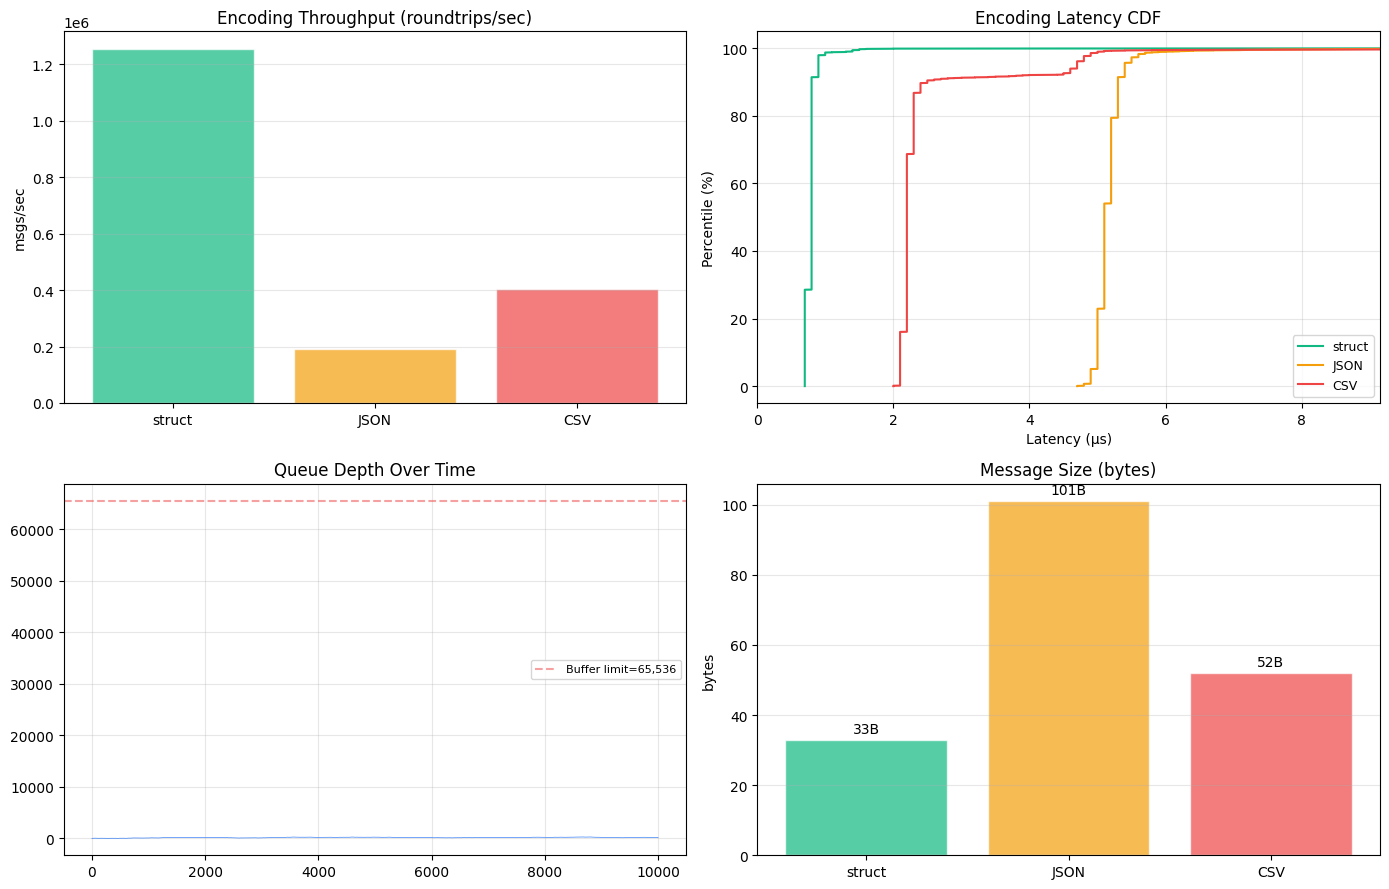

In [4]:
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Throughput comparison bar chart
fmt_names = list(results.keys())
throughputs = [sample_size / (results[f]["latencies"].sum() / 1e6) for f in fmt_names]
msg_sizes = [results[f]["msg_size"] for f in fmt_names]
colors = ["#10b981", "#f59e0b", "#ef4444"]

axes[0, 0].bar(fmt_names, throughputs, color=colors, alpha=0.7, edgecolor="white")
axes[0, 0].set_title("Encoding Throughput (roundtrips/sec)")
axes[0, 0].set_ylabel("msgs/sec")
axes[0, 0].grid(True, alpha=0.3, axis="y")

# Latency CDF per format
for fmt, color in zip(fmt_names, colors):
    lats = np.sort(results[fmt]["latencies"])
    cdf = np.arange(1, len(lats)+1) / len(lats) * 100
    axes[0, 1].plot(lats, cdf, linewidth=1.5, color=color, label=fmt)
axes[0, 1].set_xlabel("Latency (μs)")
axes[0, 1].set_ylabel("Percentile (%)")
axes[0, 1].set_title("Encoding Latency CDF")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, max(np.percentile(results[f]["latencies"], 99) for f in fmt_names) * 1.5)

# Queue depth over time
axes[1, 0].plot(queue_depths[:10000], linewidth=0.5, color="#3b82f6")
axes[1, 0].axhline(queue_size, color="#ef4444", linestyle="--", alpha=0.5, label=f"Buffer limit={queue_size:,}")
axes[1, 0].set_title("Queue Depth Over Time")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Message size comparison
axes[1, 1].bar(fmt_names, msg_sizes, color=colors, alpha=0.7, edgecolor="white")
axes[1, 1].set_title("Message Size (bytes)")
axes[1, 1].set_ylabel("bytes")
axes[1, 1].grid(True, alpha=0.3, axis="y")
# Annotate with size
for i, (name, sz) in enumerate(zip(fmt_names, msg_sizes)):
    axes[1, 1].text(i, sz + 2, f"{sz}B", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


In [5]:
import json
from datetime import datetime

results_export = {
    "project_id": "engines_02_feed_handler",
    "timestamp": datetime.now().isoformat(),
    "type": "engine_benchmark",
    "metrics": {},
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print("Results exported to results.json")


Results exported to results.json


## Summary

### Feed Handler & Order Router

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
